# Crypto vs Macro USA (FRED) — Fase 1

Notebook successivo al 02. Mentre il 02 confronta crypto con i context
asset di Yahoo (DXY, SPX, NDX, GOLD — indici), questo introduce le
**fundamentals macro** USA da FRED:

- **DFF** Fed Funds Rate, **DGS2** 2Y, **DGS10** 10Y Treasury (daily)
- **Yield curve slope** DGS10 − DGS2 (derived; recession proxy)
- **DTWEXBGS** Broad Dollar Index (daily)
- **CPIAUCSL** Consumer Price Index (monthly)
- **M2SL** Money supply M2 (monthly)
- **UNRATE** Unemployment Rate (monthly)

**Caveat metodologico**: le serie FRED monthly sono *dated* alla
release-month ma vengono *pubblicate* ~1-2 mesi dopo (CPI di gennaio
esce ~13 febbraio). Per uso retrospettivo descrittivo le date di FRED
vanno bene; per signal generation seria servirà l'allineamento a
release-date (deferred a Fase 2).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

YH_DIR = Path("../data/raw/yahoo")
FR_DIR = Path("../data/raw/fred")
sns.set_theme(style="whitegrid")

def load_daily_close(symbol: str, subdir: str) -> pd.Series:
    df = pd.read_parquet(YH_DIR / subdir / f"{symbol}_1d.parquet").sort_index()
    s = df["close"].copy()
    s.index = pd.to_datetime(s.index).normalize().tz_convert("UTC").tz_localize(None)
    s.name = symbol
    return s

def load_fred(series_id: str, freq: str) -> pd.Series:
    s = pd.read_parquet(FR_DIR / freq / f"{series_id}.parquet")["value"].copy()
    s.index = pd.to_datetime(s.index).normalize().tz_localize(None)
    s.name = series_id
    return s

# Crypto
crypto = {sym: load_daily_close(sym, "crypto") for sym in ["BTC", "ETH", "SOL", "LINK", "POL"]}
# FRED daily
fred_daily = {sid: load_fred(sid, "D") for sid in ["DFF", "DGS2", "DGS10", "DTWEXBGS"]}
# FRED monthly
fred_monthly = {sid: load_fred(sid, "M") for sid in ["CPIAUCSL", "M2SL", "UNRATE"]}

# Build derived: yield curve slope
fred_daily["SLOPE_10_2"] = (fred_daily["DGS10"] - fred_daily["DGS2"]).rename("SLOPE_10_2")

print("Crypto:", {k: len(v) for k, v in crypto.items()})
print("FRED daily:", {k: len(v) for k, v in fred_daily.items()})
print("FRED monthly:", {k: len(v) for k, v in fred_monthly.items()})


Crypto: {'BTC': 3069, 'ETH': 3069, 'SOL': 2239, 'LINK': 3069, 'POL': 2158}
FRED daily: {'DFF': 3070, 'DGS2': 2194, 'DGS10': 2194, 'DTWEXBGS': 2190, 'SLOPE_10_2': 2194}
FRED monthly: {'CPIAUCSL': 100, 'M2SL': 100, 'UNRATE': 100}


## Panel daily allineato

Crypto è 24/7, FRED daily series saltano i federal holidays. Inner-join
sulle date in cui tutte le daily hanno un valore non-NaN.


In [2]:
daily_panel = pd.concat([*crypto.values(), *fred_daily.values()], axis=1)
daily_panel = daily_panel.dropna(how="any")
print(f"Common-dates panel: {len(daily_panel)} rows")
print(f"Range: {daily_panel.index.min().date()} -> {daily_panel.index.max().date()}")
daily_panel.tail(3)


Common-dates panel: 1233 rows
Range: 2020-04-13 -> 2025-03-24


,BTC,ETH,SOL,LINK,POL,DFF,DGS2,DGS10,DTWEXBGS,SLOPE_10_2
timestamp,,,,,,,,,,
2025-03-20,84167.195312,1982.099854,127.497185,14.215102,0.211370,4.33,3.95,4.24,125.9850,0.29
2025-03-21,84043.242188,1964.847534,128.430313,13.959059,0.206306,4.33,3.94,4.25,126.2679,0.31
2025-03-24,87498.914062,2077.479004,140.869278,15.089212,0.216415,4.33,4.04,4.34,126.1956,0.30


## Variazioni: log-return per crypto, differenze per tassi/indici

I tassi in % point non vanno log-trasformati come i prezzi: usiamo la
**variazione assoluta in punti base** (Δrate × 100) per renderli
omogenei alle log-return crypto (anch'esse scalabili in percentuale).
La curve slope è già una "differenza tra rates", quindi anche lei in
punti base.


In [3]:
returns = pd.DataFrame(index=daily_panel.index)

# Log returns on prices
for sym in ["BTC", "ETH", "SOL", "LINK", "POL", "DTWEXBGS"]:
    returns[f"r_{sym}"] = np.log(daily_panel[sym]).diff()

# First differences on rates (bps = % point * 100)
for sid in ["DFF", "DGS2", "DGS10", "SLOPE_10_2"]:
    returns[f"d_{sid}"] = daily_panel[sid].diff() * 100  # in bps

returns = returns.dropna(how="any")
print(f"Daily changes panel: {len(returns)} rows")
returns.describe().round(3)


Daily changes panel: 1232 rows


,r_BTC,r_ETH,r_SOL,r_LINK,r_POL,r_DTWEXBGS,d_DFF,d_DGS2,d_DGS10,d_SLOPE_10_2
count,1232.000,1232.000,1232.000,1232.000,1232.000,1232.000,1232.000,1232.000,1232.000,1232.000
mean,0.002,0.002,0.004,0.001,0.002,0.000,0.347,0.308,0.291,-0.017
std,0.039,0.051,0.081,0.064,0.074,0.003,5.281,6.485,6.111,4.392
min,-0.257,-0.324,-0.550,-0.466,-0.391,-0.013,-50.000,-57.000,-30.000,-16.000
25%,-0.016,-0.022,-0.036,-0.033,-0.034,-0.002,0.000,-2.000,-3.000,-3.000
50%,0.001,0.002,0.001,0.002,-0.001,-0.000,0.000,0.000,0.000,0.000
75%,0.021,0.027,0.041,0.036,0.034,0.002,0.000,3.000,4.000,3.000
max,0.192,0.344,0.581,0.330,0.442,0.013,75.000,34.000,28.000,42.000


## Matrice di correlazione crypto vs macro (daily changes)

Cosa cerchiamo:
- **DFF / 10Y / 2Y vs crypto**: variazioni di tasso → crypto risponde?
- **Slope changes vs crypto**: l'irripidimento (slope ↑) è "risk-on"?
- **Broad Dollar (DTWEXBGS) vs crypto**: confronto con quanto già visto
  con DXY (notebook 02)


Crypto x macro block:


,r_DTWEXBGS,d_DFF,d_DGS2,d_DGS10,d_SLOPE_10_2
r_BTC,-0.179,-0.032,-0.057,-0.022,0.054
r_ETH,-0.193,-0.022,-0.054,-0.021,0.050
r_SOL,-0.137,-0.020,-0.024,0.001,0.036
r_LINK,-0.152,-0.020,-0.019,-0.011,0.014
r_POL,-0.173,-0.012,-0.057,-0.030,0.042


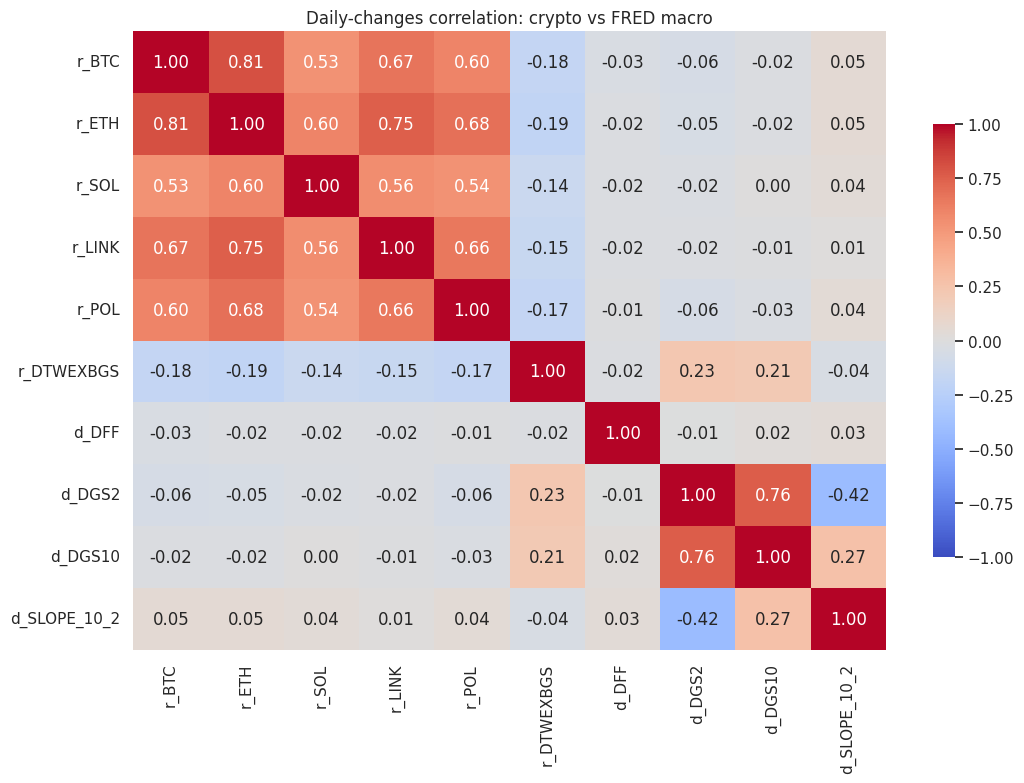

In [4]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Daily-changes correlation: crypto vs FRED macro")
plt.tight_layout()

# Focus on crypto vs macro block
crypto_rows = [c for c in corr.columns if c.startswith("r_") and c[2:] in {"BTC","ETH","SOL","LINK","POL"}]
macro_cols = [c for c in corr.columns if c.startswith("d_") or c == "r_DTWEXBGS"]
focus = corr.loc[crypto_rows, macro_cols].round(3)
print("Crypto x macro block:")
focus


## Slope della yield curve: feature stand-alone

DGS10 − DGS2. Sotto zero = curva invertita (segnale storico di
recessione 6-18 mesi avanti). Sovrappongo BTC per vedere se il pattern
tiene anche nel sample crypto.


Days inverted: 540/1233 (43.8%)

Inversion spans (>=10 consecutive days):
            days      start        end
SLOPE_10_2                            
4.0          536 2022-07-06 2022-07-06


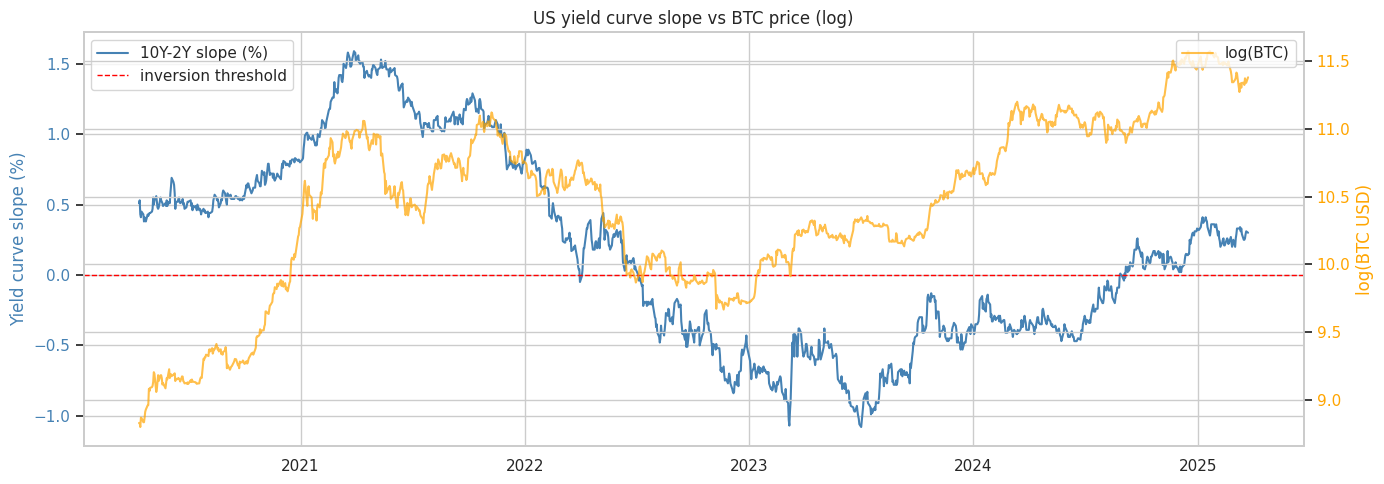

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily_panel.index, daily_panel["SLOPE_10_2"], color="steelblue", label="10Y-2Y slope (%)")
ax1.axhline(0, color="red", lw=1, ls="--", label="inversion threshold")
ax1.set_ylabel("Yield curve slope (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(daily_panel.index, np.log(daily_panel["BTC"]), color="orange", alpha=0.7, label="log(BTC)")
ax2.set_ylabel("log(BTC USD)", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

ax1.set_title("US yield curve slope vs BTC price (log)")
plt.tight_layout()

# How many days inverted, ranges
inv = daily_panel["SLOPE_10_2"] < 0
print(f"Days inverted: {inv.sum()}/{len(inv)} ({100*inv.mean():.1f}%)")
if inv.any():
    runs = (inv != inv.shift()).cumsum()[inv]
    spans = inv.groupby(runs).agg(["sum", "idxmin", "idxmax"])
    spans.columns = ["days", "start", "end"]
    print("\nInversion spans (>=10 consecutive days):")
    print(spans[spans["days"] >= 10].to_string())


## Correlazione rolling 90d: BTC vs tassi e dollaro

Le correlazioni puntuali nascondono i regimi. Rolling 90d delle daily
changes di BTC vs Δrate, Δslope, log-return DTWEXBGS.


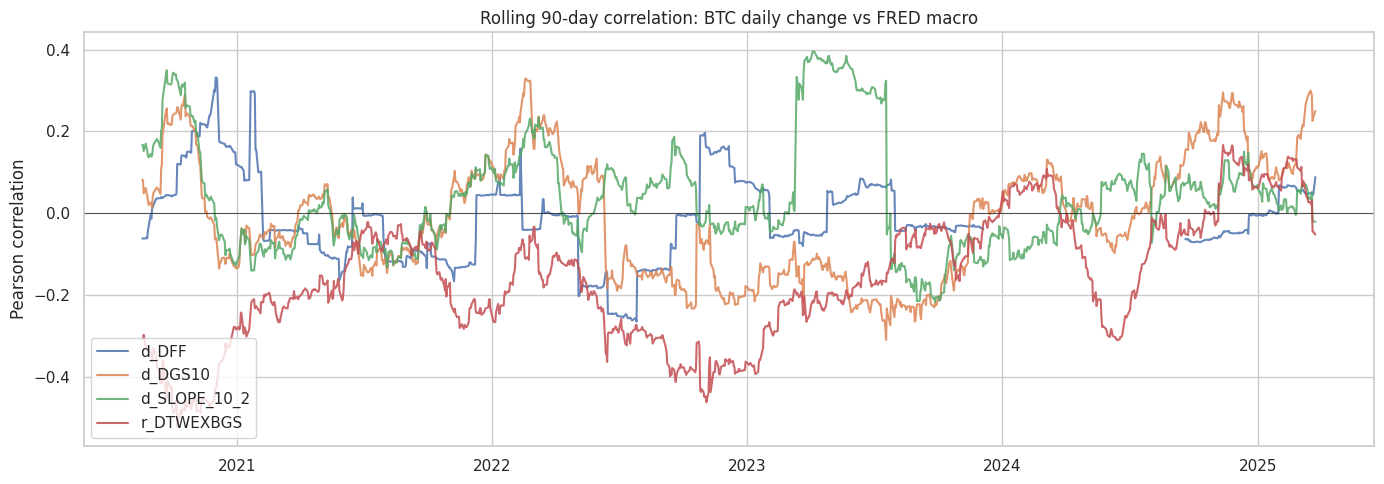

In [6]:
WINDOW = 90
fig, ax = plt.subplots(figsize=(14, 5))
for col in ["d_DFF", "d_DGS10", "d_SLOPE_10_2", "r_DTWEXBGS"]:
    rc = returns["r_BTC"].rolling(WINDOW).corr(returns[col])
    ax.plot(rc.index, rc.values, label=col, alpha=0.85)
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Rolling {WINDOW}-day correlation: BTC daily change vs FRED macro")
ax.set_ylabel("Pearson correlation")
ax.legend(loc="lower left")
plt.tight_layout()


## Aggregazione mensile: BTC vs CPI, M2, unemployment

CPI/M2/UNRATE sono pubblicate mensili. Aggrego BTC a fine mese con
log-return mensile, FRED monthly già al primo del mese. Allineo al
"month start". Useremo YoY% per le monthly macro (più segnale che m/m).


In [7]:
# Monthly BTC return: resample close to last-day-of-month, then pct_change
btc_eom = daily_panel["BTC"].resample("ME").last()
btc_monthly_ret = np.log(btc_eom).diff()

# Build monthly macro panel
monthly_macros = pd.concat([
    fred_monthly["CPIAUCSL"].rename("CPI"),
    fred_monthly["M2SL"].rename("M2"),
    fred_monthly["UNRATE"].rename("UNRATE"),
], axis=1)
# Compute YoY% changes for CPI and M2 (level series), keep UNRATE in levels (already %)
monthly_macros["CPI_yoy"] = monthly_macros["CPI"].pct_change(12) * 100
monthly_macros["M2_yoy"] = monthly_macros["M2"].pct_change(12) * 100
monthly_macros["UNRATE_change"] = monthly_macros["UNRATE"].diff()

# Align BTC EoM to month-start (FRED monthly convention) by shifting index to MS
btc_monthly_ret.index = btc_monthly_ret.index.to_period("M").to_timestamp()

monthly_panel = pd.concat([
    btc_monthly_ret.rename("BTC_logret"),
    monthly_macros[["CPI_yoy", "M2_yoy", "UNRATE_change"]],
], axis=1).dropna()

print(f"Monthly panel: {len(monthly_panel)} months ({monthly_panel.index.min().date()} -> {monthly_panel.index.max().date()})")
print("\nCorrelations (monthly):")
monthly_panel.corr().round(3)


Monthly panel: 59 months (2020-05-01 -> 2025-03-01)

Correlations (monthly):


/tmp/claude-0/ipykernel_4801/822987589.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  monthly_panel = pd.concat([


,BTC_logret,CPI_yoy,M2_yoy,UNRATE_change
BTC_logret,1.000,-0.397,0.176,-0.044
CPI_yoy,-0.397,1.000,-0.307,0.371
M2_yoy,0.176,-0.307,1.000,-0.596
UNRATE_change,-0.044,0.371,-0.596,1.000


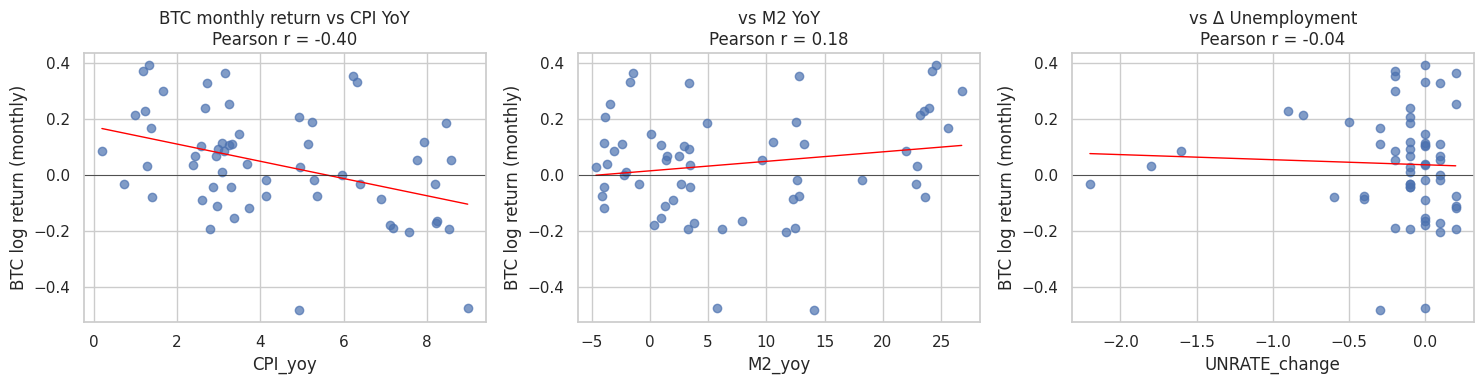

In [8]:
# Scatter: BTC monthly return vs CPI YoY (inflation regime hypothesis)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ["CPI_yoy", "M2_yoy", "UNRATE_change"],
    ["BTC monthly return vs CPI YoY", "vs M2 YoY", "vs Δ Unemployment"]
):
    ax.scatter(monthly_panel[col], monthly_panel["BTC_logret"], alpha=0.7)
    z = np.polyfit(monthly_panel[col], monthly_panel["BTC_logret"], 1)
    xs = np.linspace(monthly_panel[col].min(), monthly_panel[col].max(), 100)
    ax.plot(xs, z[0]*xs + z[1], color="red", lw=1)
    r = monthly_panel[col].corr(monthly_panel["BTC_logret"])
    ax.set_title(f"{title}\nPearson r = {r:.2f}")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel("BTC log return (monthly)")
plt.tight_layout()


## Note metodologiche e prossimi passi

- **Look-ahead bias**: CPI/M2/UNRATE hanno data di pubblicazione che
  posticipa la data nominale di ~1-2 mesi. In questa EDA descrittiva
  uso le FRED date direttamente, ma per signal generation (Fase 2) va
  costruito un allineamento a *release date*
- **Slope inversion**: il pattern storico è "inversion → recessione
  6-18 mesi dopo". Nel nostro sample BTC 2018-2026 abbiamo già visto
  un episodio. Marcarlo su grafico (recessione NBER se disponibile da
  FRED → serie `USREC`) sarebbe utile per il prossimo notebook
- **Correlazioni mensili e dimensionalità**: il monthly panel ha ~80
  osservazioni — la correlazione Pearson su 80 punti ha alta varianza,
  i valori vanno presi con intervallo di confidenza (bootstrap o
  Spearman come check)
- **Direzione Fase 2**: queste rolling correlations crypto-rates +
  yield slope sono potenziali **regime features** per un
  Hidden-Markov-Model (HMM) o un k-means semplice sui rolling
  correlation vectors. Il segnale "regime" può poi servire come
  conditioning variable nei modelli predictive
